# Trajectory Inference Tests

Test the new simulation-based trajectory inference for various pulse sequences.

In [12]:
import sys
from pathlib import Path
sys.path.insert(0, '..')

import numpy as np
import matplotlib.pyplot as plt
import lmt_sim.lmt_simulation as sim
import lmt_sim.lmt_sequence as seq
from scipy import constants as scipy_constants
import version_info as vs

In [13]:
CLOCK_SHELVING_PULSE_TIME = 380e-6
SHELVING_PULSE_CLEAROUT_DURATION = 2200e-6
LMT_SELECTIVE_PI_TIME = 95e-6
LMT_PULSE_CLEAROUT_DURATION = 50e-6
GRAVITY_DOPPLER_PER_SEC_HZ = (
    sim.TRANSITION_FREQUENCY * scipy_constants.g / scipy_constants.c
)


def insert_clearouts_preserving_pulse_timing(sequence, placements):
    sequence = list(sequence)
    for mode, pulse_index, clearout_duration, label in reversed(placements):
        if mode == "after":
            freefall_index = pulse_index + 1
            if freefall_index >= len(sequence) or not isinstance(
                sequence[freefall_index], seq.Freefall
            ):
                raise ValueError(
                    f"Cannot insert {label} after pulse index {pulse_index}: expected a following Freefall"
                )
            freefall = sequence[freefall_index]
            if freefall.duration < clearout_duration:
                raise ValueError(
                    f"Cannot insert {label}: following Freefall is shorter than {clearout_duration * 1e6:.1f} us"
                )

            replacement = [seq.Clearout(duration=clearout_duration, label=label)]
            remaining_duration = freefall.duration - clearout_duration
            if remaining_duration > 0.0:
                replacement.append(
                    seq.Freefall(duration=remaining_duration, label=freefall.label)
                )
            sequence[freefall_index : freefall_index + 1] = replacement
        elif mode == "before":
            freefall_index = pulse_index - 1
            if freefall_index < 0 or not isinstance(
                sequence[freefall_index], seq.Freefall
            ):
                raise ValueError(
                    f"Cannot insert {label} before pulse index {pulse_index}: expected a preceding Freefall"
                )
            freefall = sequence[freefall_index]
            if freefall.duration < clearout_duration:
                raise ValueError(
                    f"Cannot insert {label}: preceding Freefall is shorter than {clearout_duration * 1e6:.1f} us"
                )

            replacement = []
            remaining_duration = freefall.duration - clearout_duration
            if remaining_duration > 0.0:
                replacement.append(
                    seq.Freefall(duration=remaining_duration, label=freefall.label)
                )
            replacement.append(seq.Clearout(duration=clearout_duration, label=label))
            sequence[freefall_index : freefall_index + 1] = replacement
        else:
            raise ValueError(f"Unsupported clearout placement mode: {mode!r}")

    return sequence


def add_true_lmt_clearouts(sequence, duration_tolerance=1e-6):
    if any(isinstance(event, seq.Clearout) for event in sequence):
        raise ValueError("Sequence already contains Clearout events")

    velocity_selection_indices = [
        i
        for i, event in enumerate(sequence)
        if isinstance(event, seq.Pulse)
        and np.isclose(
            event.duration,
            CLOCK_SHELVING_PULSE_TIME,
            atol=duration_tolerance,
            rtol=0.0,
        )
    ]
    if len(velocity_selection_indices) != 1:
        raise ValueError(
            f"Expected exactly one velocity-selection pulse in extracted sequence, found {len(velocity_selection_indices)}"
        )

    selective_indices = [
        i
        for i, event in enumerate(sequence)
        if isinstance(event, seq.Pulse)
        and np.isclose(
            event.duration,
            LMT_SELECTIVE_PI_TIME,
            atol=duration_tolerance,
            rtol=0.0,
        )
    ]
    if len(selective_indices) != 4:
        raise ValueError(
            "Expected exactly four selective 95 us pulses in extracted sequence"
        )

    placements = [
        (
            "after",
            velocity_selection_indices[0],
            SHELVING_PULSE_CLEAROUT_DURATION,
            "vs_clearout",
        ),
        (
            "after",
            selective_indices[0],
            LMT_PULSE_CLEAROUT_DURATION,
            "clearout_after_first_sel_upper",
        ),
        (
            "before",
            selective_indices[1],
            LMT_PULSE_CLEAROUT_DURATION,
            "clearout_before_last_sel_upper",
        ),
        (
            "after",
            selective_indices[2],
            LMT_PULSE_CLEAROUT_DURATION,
            "clearout_after_first_sel_lower",
        ),
        (
            "before",
            selective_indices[3],
            LMT_PULSE_CLEAROUT_DURATION,
            "clearout_before_last_sel_lower",
        ),
    ]
    return insert_clearouts_preserving_pulse_timing(sequence, placements)


def build_sequence_from_lab_pulse_dump(
    is_up,
    start_times_mu,
    durations_mu,
    opll_hz,
    beam_hz,
    *,
    pi_pulse_threshold_s=50e-6,
    compensate_gravity=True,
):
    if pi_pulse_threshold_s <= 0.0:
        raise ValueError("pi_pulse_threshold_s must be positive")

    is_up = np.asarray(is_up, dtype=bool)
    start_times_mu = np.asarray(start_times_mu, dtype=float)
    durations_mu = np.asarray(durations_mu, dtype=float)
    opll_hz = np.asarray(opll_hz, dtype=float)
    beam_hz = np.asarray(beam_hz, dtype=float)

    lengths = {
        len(is_up),
        len(start_times_mu),
        len(durations_mu),
        len(opll_hz),
        len(beam_hz),
    }
    if len(lengths) != 1:
        raise ValueError("Lab pulse dump arrays must all have the same length")

    timestamps = start_times_mu * 1e-9
    durations = durations_mu * 1e-9
    total_laser_frequency_hz = opll_hz + beam_hz

    if compensate_gravity:
        beam_sign = np.where(is_up, 1.0, -1.0)
        total_laser_frequency_hz = (
            total_laser_frequency_hz
            - GRAVITY_DOPPLER_PER_SEC_HZ * timestamps * beam_sign
        )

    centre_freq_hz = total_laser_frequency_hz[0] - sim.RECOIL_FREQUENCY_HZ

    sequence = []
    t_now = 0.0

    for this_is_up, this_timestamp, this_duration, this_total_laser_hz in zip(
        is_up,
        timestamps,
        durations,
        total_laser_frequency_hz,
    ):
        if this_timestamp < t_now:
            raise ValueError(
                f"Pulse timestamps must be non-decreasing. Got {this_timestamp} < {t_now}."
            )
        if this_timestamp > t_now:
            sequence.append(seq.Freefall(duration=this_timestamp - t_now))
            t_now = this_timestamp

        if this_duration > pi_pulse_threshold_s:
            rabi_freq_hz = 1 / (2 * this_duration)
        else:
            rabi_freq_hz = 1 / (4 * this_duration)

        sequence.append(
            seq.Pulse(
                k=+1 if this_is_up else -1,
                detuning_hz=this_total_laser_hz - centre_freq_hz,
                phi=0.0,
                label="LMT",
                rabi_frequency=rabi_freq_hz,
                duration=this_duration,
            )
        )
        t_now += this_duration

    return sequence, total_laser_frequency_hz

In [14]:
pulse_sequence = [[[1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0], [4936, 2690399, 2793088, 2921088, 3036088, 3164088, 3279088, 3407088, 3522088, 3650088, 3765088, 3893088, 4008088, 4136088, 4251088, 4379088, 4494088, 4622088, 6689087, 6756086, 6836085, 6903084, 6983083, 7050082, 7130081, 7197080, 7277079, 7344078, 7424077, 7491076, 7571075, 7638074, 7718073, 7785072, 7865071, 7932070, 8017247, 8253791, 8445576, 8796416, 8924416, 9039416, 9167416, 9282416, 9410416, 9525416, 9653416, 9768416, 9896416, 10011416, 10139416, 10254416, 10382416, 10497416, 10625416, 10740416, 10868416, 10983416, 11111416, 11226416, 11354416, 11469416, 11597416, 11712416, 11840416, 11955416, 12083416, 12198416, 12326416, 12441416, 12569416, 12684416, 12812416, 12927416, 13055416, 13170416, 13298416, 13413416, 13591423, 13719423, 13834423, 13962423, 14077423, 14205423, 14320423, 14448423, 14563423, 14691423, 14806423, 14934423, 15049423, 15177423, 15292423, 15420423, 15535423, 15663423, 15778423, 15906423, 16021423, 16149423, 16264423, 16392423, 16507423, 16635423, 16750423, 16878423, 16993423, 17121423, 17236423, 17364423, 17479423, 17607423, 17722423, 17850423, 17965423, 18093423, 18208423, 18544224, 18695056, 18869584, 19220424, 19348424, 19463424, 19591424, 19706424, 19834424, 19949424, 20077424, 20192424, 20320424, 20435424, 20563424, 20678424, 20806424, 20921424, 21049424, 21164424, 21292424, 21407424, 21535424, 21650424, 21778424, 21893424, 22021424, 22136424, 22264424, 22379424, 22507424, 22622424, 22750424, 22865424, 22993424, 23108424, 23236424, 23351424, 23479424, 23594424, 23722424, 23837424, 24015432, 24143432, 24258432, 24386432, 24501432, 24629432, 24744432, 24872432, 24987432, 25115432, 25230432, 25358432, 25473432, 25601432, 25716432, 25844432, 25959432, 26087432, 26202432, 26330432, 26445432, 26573432, 26688432, 26816432, 26931432, 27059432, 27174432, 27302432, 27417432, 27545432, 27660432, 27788432, 27903432, 28031432, 28146432, 28274432, 28389432, 28517432, 28632432, 28968232, 29172736], [380000, 34000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 30555, 34000, 94999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 94999, 68000, 94999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 94999, 34000], [80000000, 79972625, 79989183, 80003413, 80004571, 79988025, 80019959, 79972637, 80035347, 79957249, 80050735, 79941861, 80066124, 79926473, 80081512, 79911085, 80096900, 79895696, 80093918, 79914540, 80077182, 79931276, 80060446, 79948012, 80043710, 79964748, 80026974, 79981484, 80010238, 79998220, 79993502, 80014956, 79976766, 80031692, 79960030, 80048428, 79943798, 80062711, 79930712, 80074092, 79918504, 80089480, 79903116, 80104868, 79887728, 80120257, 79872340, 80135645, 79856952, 80151033, 79841563, 80166421, 79826175, 80181809, 79810787, 80197197, 79795399, 80212585, 79780011, 80227973, 79764623, 80243361, 79749235, 80258750, 79733847, 80274138, 79718458, 80289526, 79703070, 80304914, 79687682, 80320302, 79672294, 80335690, 79656906, 80351078, 79641518, 80366466, 80363767, 79647429, 80341555, 79669641, 80319343, 79691853, 80297131, 79714065, 80274920, 79736277, 80252708, 79758489, 80230496, 79780700, 80208284, 79802912, 80186072, 79825124, 80163860, 79847336, 80141648, 79869548, 80119436, 79891760, 80097224, 79913972, 80075013, 79936184, 80052801, 79958396, 80030589, 79980607, 80008377, 80002819, 79986165, 80025031, 79963953, 80047243, 79941741, 80072304, 79915909, 80076872, 79927532, 80064864, 79942920, 80049476, 79958308, 80034088, 79973696, 80018700, 79989085, 80003312, 80004473, 79987924, 80019861, 79972535, 80035249, 79957147, 80050637, 79941759, 80066025, 79926371, 80081413, 79910983, 80096801, 79895595, 80112189, 79880207, 80127578, 79864819, 80142966, 79849430, 80158354, 79834042, 80173742, 79818654, 80189130, 79803266, 80204518, 79787878, 80219906, 80217407, 79793789, 80195195, 79816001, 80172983, 79838213, 80150771, 79860425, 80128559, 79882637, 80106348, 79904849, 80084136, 79927061, 80061924, 79949272, 80039712, 79971484, 80017500, 79993696, 79995288, 80015908, 79973076, 80038120, 79950864, 80060332, 79928652, 80082544, 79906441, 80104756, 79884229, 80126968, 79862017, 80149179, 79839805, 80171391, 79817593, 80193603, 79795381, 80217664, 79769064], [200000000, 200005800, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200005800, 200000500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200005800, 200000500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200005800]], [[1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0], [4936, 2690399, 2993088, 3121088, 3236088, 3364088, 3479088, 3607088, 3722088, 3850088, 3965088, 4093088, 4208088, 4336088, 4451088, 4579088, 4694088, 4822088, 6889087, 6956086, 7036085, 7103084, 7183083, 7250082, 7330081, 7397080, 7477079, 7544078, 7624077, 7691076, 7771075, 7838074, 7918073, 7985072, 8065071, 8132070, 8217247, 8453791, 8645576, 8996416, 9124416, 9239416, 9367416, 9482416, 9610416, 9725416, 9853416, 9968416, 10096416, 10211416, 10339416, 10454416, 10582416, 10697416, 10825416, 10940416, 11068416, 11183416, 11311416, 11426416, 11554416, 11669416, 11797416, 11912416, 12040416, 12155416, 12283416, 12398416, 12526416, 12641416, 12769416, 12884416, 13012416, 13127416, 13255416, 13370416, 13498416, 13613416, 13791423, 13919423, 14034423, 14162423, 14277423, 14405423, 14520423, 14648423, 14763423, 14891423, 15006423, 15134423, 15249423, 15377423, 15492423, 15620423, 15735423, 15863423, 15978423, 16106423, 16221423, 16349423, 16464423, 16592423, 16707423, 16835423, 16950423, 17078423, 17193423, 17321423, 17436423, 17564423, 17679423, 17807423, 17922423, 18050423, 18165423, 18293423, 18408423, 18744224, 18895056, 19069584, 19420424, 19548424, 19663424, 19791424, 19906424, 20034424, 20149424, 20277424, 20392424, 20520424, 20635424, 20763424, 20878424, 21006424, 21121424, 21249424, 21364424, 21492424, 21607424, 21735424, 21850424, 21978424, 22093424, 22221424, 22336424, 22464424, 22579424, 22707424, 22822424, 22950424, 23065424, 23193424, 23308424, 23436424, 23551424, 23679424, 23794424, 23922424, 24037424, 24215432, 24343432, 24458432, 24586432, 24701432, 24829432, 24944432, 25072432, 25187432, 25315432, 25430432, 25558432, 25673432, 25801432, 25916432, 26044432, 26159432, 26287432, 26402432, 26530432, 26645432, 26773432, 26888432, 27016432, 27131432, 27259432, 27374432, 27502432, 27617432, 27745432, 27860432, 27988432, 28103432, 28231432, 28346432, 28474432, 28589432, 28717432, 28832432, 29168232, 29372736], [380000, 34000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 30555, 34000, 94999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 94999, 68000, 94999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 54999, 68000, 94999, 34000], [80000000, 79972625, 79986375, 80006221, 80001763, 79990833, 80017151, 79975445, 80032539, 79960057, 80047927, 79944669, 80063315, 79929281, 80078704, 79913893, 80094092, 79898505, 80096727, 79911732, 80079991, 79928468, 80063255, 79945204, 80046518, 79961940, 80029782, 79978676, 80013046, 79995412, 79996310, 80012148, 79979574, 80028884, 79962838, 80045620, 79946606, 80059903, 79933520, 80071284, 79921312, 80086672, 79905924, 80102060, 79890536, 80117448, 79875148, 80132837, 79859760, 80148225, 79844372, 80163613, 79828983, 80179001, 79813595, 80194389, 79798207, 80209777, 79782819, 80225165, 79767431, 80240553, 79752043, 80255941, 79736655, 80271330, 79721267, 80286718, 79705879, 80302106, 79690490, 80317494, 79675102, 80332882, 79659714, 80348270, 79644326, 80363658, 80360959, 79650237, 80338747, 79672449, 80316535, 79694661, 80294323, 79716873, 80272111, 79739085, 80249900, 79761297, 80227688, 79783509, 80205476, 79805720, 80183264, 79827932, 80161052, 79850144, 80138840, 79872356, 80116628, 79894568, 80094416, 79916780, 80072204, 79938992, 80049993, 79961204, 80027781, 79983416, 80005569, 80005627, 79983357, 80027839, 79961145, 80050051, 79938933, 80075112, 79913100, 80079680, 79924724, 80067672, 79940112, 80052284, 79955500, 80036896, 79970888, 80021508, 79986276, 80006120, 80001665, 79990732, 80017053, 79975344, 80032441, 79959955, 80047829, 79944567, 80063217, 79929179, 80078605, 79913791, 80093993, 79898403, 80109381, 79883015, 80124769, 79867627, 80140158, 79852239, 80155546, 79836851, 80170934, 79821462, 80186322, 79806074, 80201710, 79790686, 80217098, 80214599, 79796597, 80192387, 79818809, 80170175, 79841021, 80147963, 79863233, 80125751, 79885445, 80103539, 79907657, 80081327, 79929869, 80059116, 79952081, 80036904, 79974292, 80014692, 79996504, 79992480, 80018716, 79970268, 80040928, 79948056, 80063140, 79925844, 80085352, 79903632, 80107564, 79881421, 80129776, 79859209, 80151988, 79836997, 80174199, 79814785, 80196411, 79792573, 80220472, 79766256], [200000500, 200005800, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200005800, 200000500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200005800, 200000500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200001500, 200005800, 200000500, 200005800]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]], [[-1]]]

In [15]:
(
    is_up,
    start_times_mu,
    durations_mu,
    opll_hz,
    beam_hz,
) = pulse_sequence[0]

is_up = np.array(is_up)
start_times_mu = np.array(start_times_mu)
durations_mu = np.array(durations_mu)
opll_hz = np.array(opll_hz)
beam_hz = np.array(beam_hz)

In [16]:
# Manually specify which durations are pi pulses and which are pi/2
is_pi_pulse = lambda d: d > 50000e-9

In [17]:
sequence, sequence_laser_hz = build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_mu=start_times_mu,
    durations_mu=durations_mu,
    opll_hz=opll_hz,
    beam_hz=beam_hz,
)

# Skip the first freefall
sequence = sequence[1:]

In [18]:
sequence = add_true_lmt_clearouts(sequence)

In [19]:
sequence = sequence[:15]
sequence

[Pulse(k=1, detuning_hz=np.float64(4707.028607964516), phi=0.0, label='LMT', rabi_frequency=np.float64(1315.7894736842104), duration=np.float64(0.00038), beam_waist=1000000.0),
 Clearout(duration=0.0022, label='vs_clearout'),
 Freefall(duration=np.float64(0.00010546299999999965), label='freefall'),
 Pulse(k=-1, detuning_hz=np.float64(21000.51998013258), phi=0.0, label='LMT', rabi_frequency=np.float64(7352.941176470588), duration=np.float64(3.4e-05), beam_waist=1000000.0),
 Freefall(duration=np.float64(6.868899999999982e-05), label='freefall'),
 Pulse(k=-1, detuning_hz=np.float64(39001.26365035772), phi=0.0, label='LMT', rabi_frequency=np.float64(7352.941176470588), duration=np.float64(6.8e-05), beam_waist=1000000.0),
 Freefall(duration=np.float64(6.000000000000016e-05), label='freefall'),
 Pulse(k=1, detuning_hz=np.float64(-31350.862524986267), phi=0.0, label='LMT', rabi_frequency=np.float64(9091.074383170602), duration=np.float64(5.4999000000000007e-05), beam_waist=1000000.0),
 Freefa

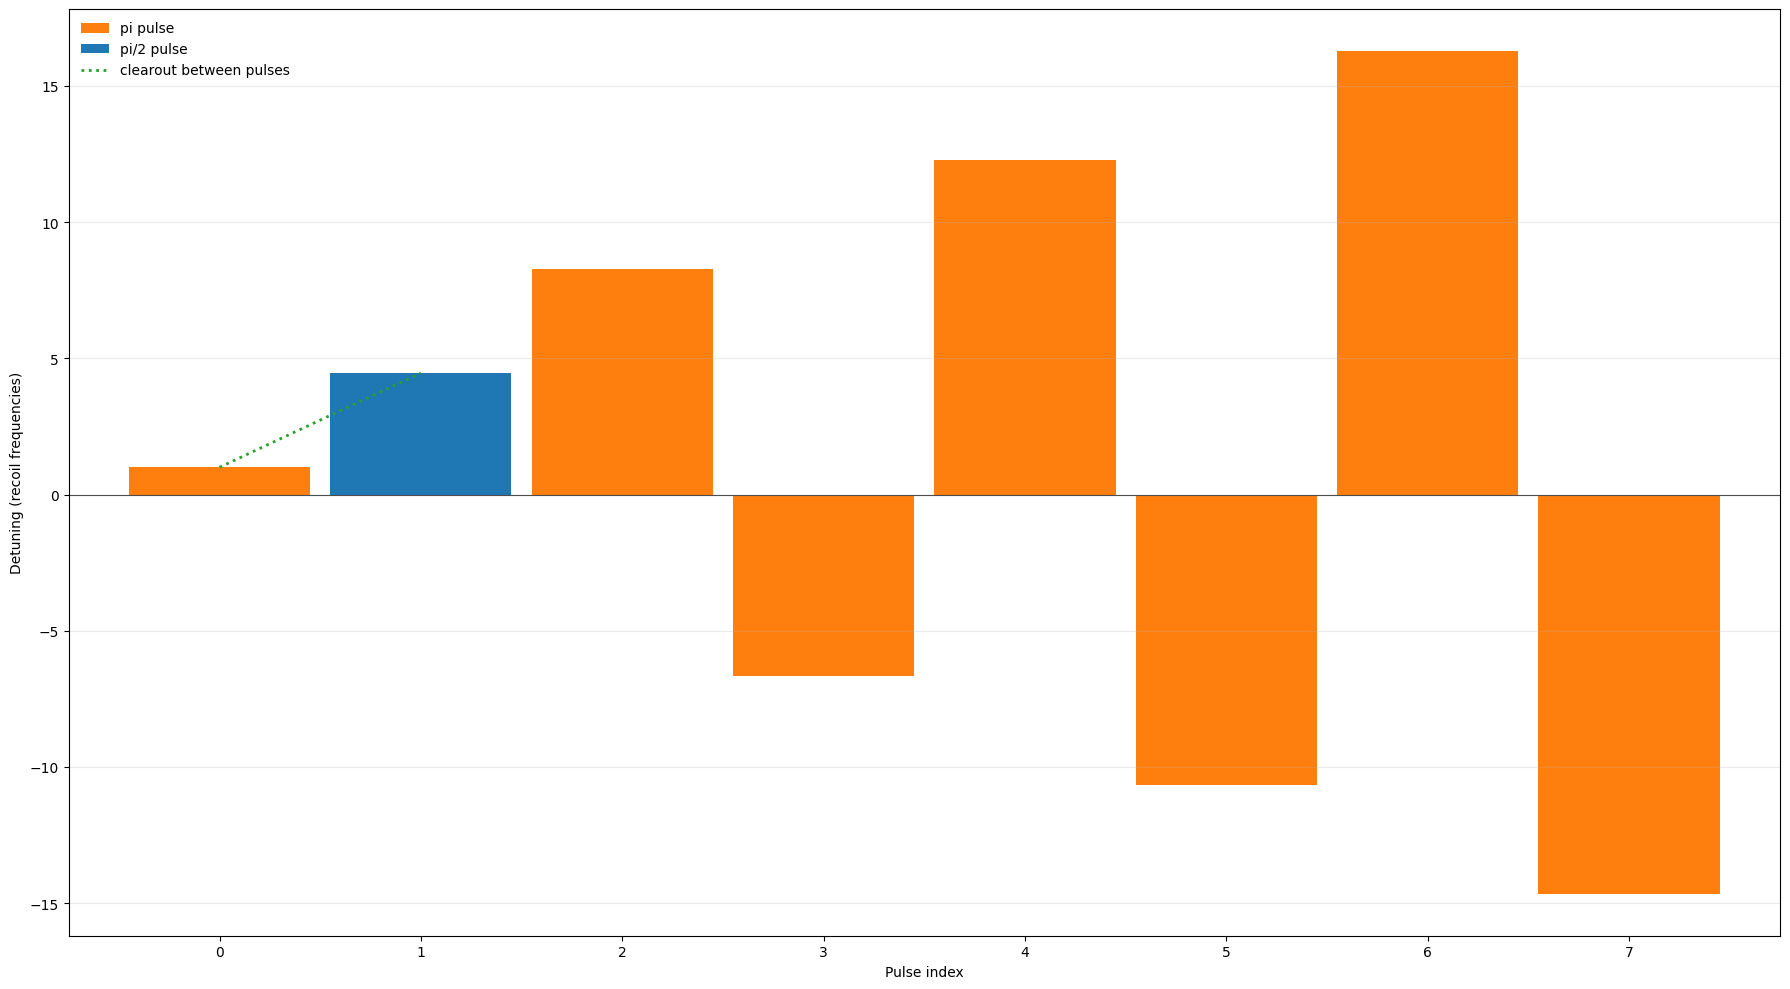

In [28]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plot_sequence, _ = build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_mu=start_times_mu,
    durations_mu=durations_mu,
    opll_hz=opll_hz,
    beam_hz=beam_hz,
)
plot_sequence = add_true_lmt_clearouts(plot_sequence[1:])

# Truncate
plot_sequence = plot_sequence[:16]

pulse_detunings_recoil = []
pulse_colours = []
clearout_links = []

last_pulse_index = None
clearout_since_last_pulse = False

for event in plot_sequence:
    if isinstance(event, seq.Clearout):
        clearout_since_last_pulse = True
        continue

    if not isinstance(event, seq.Pulse):
        continue

    pulse_index = len(pulse_detunings_recoil)
    pulse_detunings_recoil.append(event.detuning_hz / sim.RECOIL_FREQUENCY_HZ)
    pulse_colours.append("tab:orange" if is_pi_pulse(event.duration) else "tab:blue")

    if last_pulse_index is not None and clearout_since_last_pulse:
        clearout_links.append((last_pulse_index, pulse_index))

    last_pulse_index = pulse_index
    clearout_since_last_pulse = False

pulse_indices = np.arange(len(pulse_detunings_recoil))

fig, ax = plt.subplots(figsize=(18, 10))
ax.bar(pulse_indices, pulse_detunings_recoil, color=pulse_colours, width=0.9)

for left_index, right_index in clearout_links:
    ax.plot(
        [left_index, right_index],
        [
            pulse_detunings_recoil[left_index],
            pulse_detunings_recoil[right_index],
        ],
        color="tab:green",
        linestyle=":",
        linewidth=2,
        zorder=3,
    )

tick_step = max(1, len(pulse_indices) // 20)
ax.set_xticks(pulse_indices[::tick_step])
ax.set_xlim(-0.75, len(pulse_indices) - 0.25)
ax.set_xlabel("Pulse index")
ax.set_ylabel("Detuning (recoil frequencies)")
ax.axhline(0.0, color="0.3", linewidth=0.8)
ax.grid(axis="y", alpha=0.25)

legend_handles = [
    Patch(facecolor="tab:orange", label="pi pulse"),
    Patch(facecolor="tab:blue", label="pi/2 pulse"),
]
if clearout_links:
    legend_handles.append(
        Line2D(
            [0],
            [0],
            color="tab:green",
            linestyle=":",
            linewidth=2,
            label="clearout between pulses",
        )
    )

ax.legend(handles=legend_handles, loc="upper left", frameon=False)
plt.tight_layout()

plt.savefig("lab_pulse_sequence.png", dpi=300)

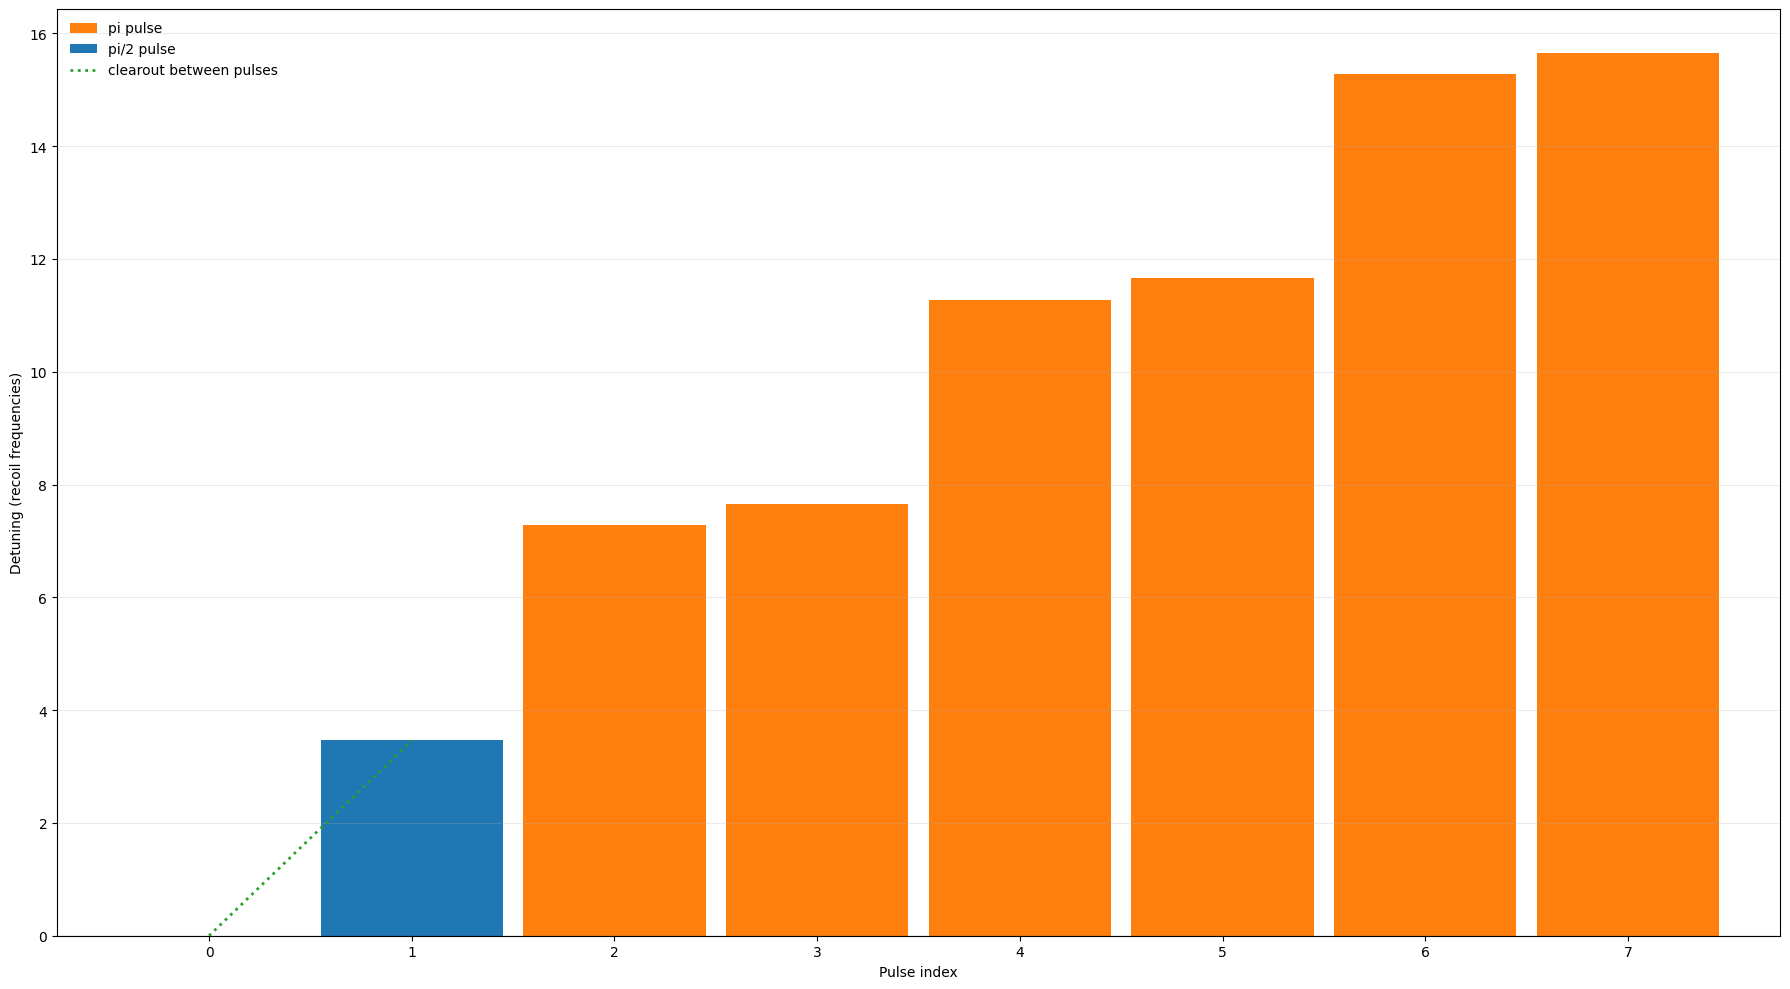

In [36]:
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

plot_sequence, _ = build_sequence_from_lab_pulse_dump(
    is_up=is_up,
    start_times_mu=start_times_mu,
    durations_mu=durations_mu,
    opll_hz=opll_hz,
    beam_hz=beam_hz,
)
plot_sequence = add_true_lmt_clearouts(plot_sequence[1:])

# Truncate
plot_sequence = plot_sequence[:16]

pulse_detunings_recoil = []
pulse_colours = []
clearout_links = []

last_pulse_index = None
clearout_since_last_pulse = False

reference_detuning = None

for event in plot_sequence:
    if isinstance(event, seq.Clearout):
        clearout_since_last_pulse = True
        continue

    if not isinstance(event, seq.Pulse):
        continue

    if reference_detuning is None:
        reference_detuning = event.detuning_hz

    pulse_index = len(pulse_detunings_recoil)
    pulse_detunings_recoil.append(np.abs(event.detuning_hz - reference_detuning) / sim.RECOIL_FREQUENCY_HZ)
    pulse_colours.append("tab:orange" if is_pi_pulse(event.duration) else "tab:blue")

    if last_pulse_index is not None and clearout_since_last_pulse:
        clearout_links.append((last_pulse_index, pulse_index))

    last_pulse_index = pulse_index
    clearout_since_last_pulse = False

pulse_indices = np.arange(len(pulse_detunings_recoil))

fig, ax = plt.subplots(figsize=(18, 10))
ax.bar(pulse_indices, pulse_detunings_recoil, color=pulse_colours, width=0.9)

for left_index, right_index in clearout_links:
    ax.plot(
        [left_index, right_index],
        [
            pulse_detunings_recoil[left_index],
            pulse_detunings_recoil[right_index],
        ],
        color="tab:green",
        linestyle=":",
        linewidth=2,
        zorder=3,
    )

tick_step = max(1, len(pulse_indices) // 20)
ax.set_xticks(pulse_indices[::tick_step])
ax.set_xlim(-0.75, len(pulse_indices) - 0.25)
ax.set_xlabel("Pulse index")
ax.set_ylabel("Detuning (recoil frequencies)")
ax.axhline(0.0, color="0.3", linewidth=0.8)
ax.grid(axis="y", alpha=0.25)

legend_handles = [
    Patch(facecolor="tab:orange", label="pi pulse"),
    Patch(facecolor="tab:blue", label="pi/2 pulse"),
]
if clearout_links:
    legend_handles.append(
        Line2D(
            [0],
            [0],
            color="tab:green",
            linestyle=":",
            linewidth=2,
            label="clearout between pulses",
        )
    )

ax.legend(handles=legend_handles, loc="upper left", frameon=False)
plt.tight_layout()

plt.savefig("lab_pulse_sequence.png", dpi=300)

In [42]:
 (sim.RECOIL_FREQUENCY_HZ * 2 - 9400 ) * 30

421.7164782765576

In [45]:
421 / (1 / 55e-6)

0.023155000000000002

([compute_spacetime_trajectory.<locals>.Cloud(times=[0.0, np.float64(0.00038), np.float64(0.0025800000000000003), np.float64(0.002685463), np.float64(0.002719463), np.float64(0.002788152), np.float64(0.002856152), np.float64(0.002916152), np.float64(0.002971151), np.float64(0.003031152), np.float64(0.003099152), np.float64(0.003159152), np.float64(0.003214151), np.float64(0.0032741520000000002), np.float64(0.003342152), np.float64(0.0034021520000000003)], z=[0.0, np.float64(2.4969845359566025e-06), np.float64(1.6953210796757987e-05), np.float64(1.764620942864112e-05), np.float64(1.786962383448987e-05), np.float64(1.832098007341177e-05), np.float64(1.876780888510927e-05), np.float64(1.9162069601312944e-05), np.float64(1.9523468686821042e-05), np.float64(1.9917735974036654e-05), np.float64(2.036456478573415e-05), np.float64(2.0758825501937827e-05), np.float64(2.1120224587445925e-05), np.float64(2.1514491874661537e-05), np.float64(2.1961320686359034e-05), np.float64(2.235558140256271e-05)

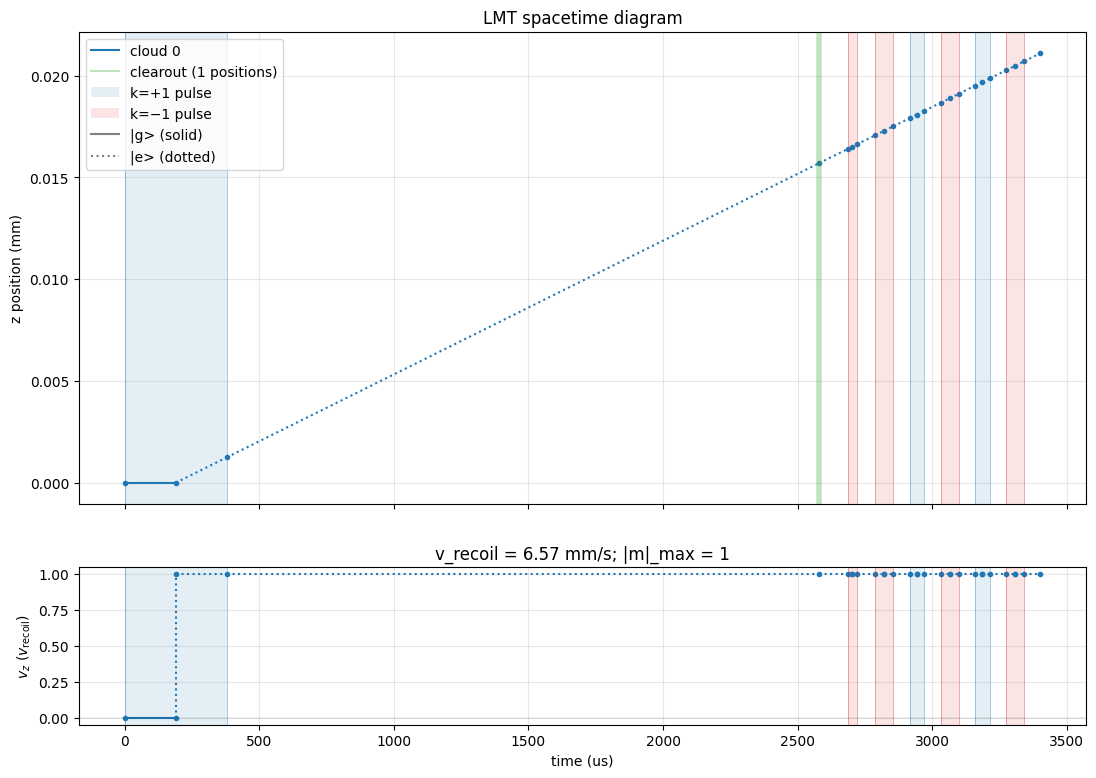

In [21]:
seq.compute_spacetime_trajectory(sequence, plot=True, max_branches=20)


In [22]:
sequence

[Pulse(k=1, detuning_hz=np.float64(4707.028607964516), phi=0.0, label='LMT', rabi_frequency=np.float64(1315.7894736842104), duration=np.float64(0.00038), beam_waist=1000000.0),
 Clearout(duration=0.0022, label='vs_clearout'),
 Freefall(duration=np.float64(0.00010546299999999965), label='freefall'),
 Pulse(k=-1, detuning_hz=np.float64(21000.51998013258), phi=0.0, label='LMT', rabi_frequency=np.float64(7352.941176470588), duration=np.float64(3.4e-05), beam_waist=1000000.0),
 Freefall(duration=np.float64(6.868899999999982e-05), label='freefall'),
 Pulse(k=-1, detuning_hz=np.float64(39001.26365035772), phi=0.0, label='LMT', rabi_frequency=np.float64(7352.941176470588), duration=np.float64(6.8e-05), beam_waist=1000000.0),
 Freefall(duration=np.float64(6.000000000000016e-05), label='freefall'),
 Pulse(k=1, detuning_hz=np.float64(-31350.862524986267), phi=0.0, label='LMT', rabi_frequency=np.float64(9091.074383170602), duration=np.float64(5.4999000000000007e-05), beam_waist=1000000.0),
 Freefa